In [1]:
from datamodel import TradingState, Listing, OrderDepth, Observation, Symbol, Trade, Position, Order
from backtester import Backtester
from typing import Dict, List
from trader import Trader
import matplotlib.pyplot as plt
from visualizer import BacktestingResult
import numpy as np
import json

In [2]:
import json
from datamodel import OrderDepth, TradingState, Order
from typing import Dict, List




class UserTrader(Trader):
    def __init__(self):
        self.result = {}
        
    def trade_elemeralds(self, state: TradingState):
        self.result["EMERALDS"]=[]
        LIMIT = 50
        position = state.position.get("EMERALDS", 0)
        if position >= LIMIT: # flatten position to 0
           self.result["EMERALDS"].append(Order("EMERALDS", 10000, -state.position["EMERALDS"]))
           return
        elif position <= -LIMIT: # flatten position to 0
           self.result["EMERALDS"].append(Order("EMERALDS", 10000, abs(state.position["EMERALDS"])))
           return 
        
        best_bid = max(state.order_depths["EMERALDS"].buy_orders)
        best_ask = min(state.order_depths["EMERALDS"].sell_orders)

        bid_quote = best_bid + 1
        ask_quote = best_ask - 1

        if bid_quote < 10000 and ask_quote > 10000:
            self.result["EMERALDS"].append(Order("EMERALDS", bid_quote, 5))
            self.result["EMERALDS"].append(Order("EMERALDS", ask_quote, -5))

    def trade_tomatoes(self, state: TradingState):
        self.result["TOMATOES"]=[]
    def run(self, state: TradingState):
        self.trade_elemeralds(state)
        self.trade_tomatoes(state)

        return self.result, 0, ""

In [3]:
backtesting_engine = Backtester("./data/prices2.csv", "./data/trades.csv")

c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("", 0)
c:\Projects\IMC_PROSPERITY_4\backtesting_engine\data_parser.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buyer"].replace(0, "", inplace=True)
c:\Project

In [4]:
sample_trader = UserTrader()
backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)

In [ ]:
total_runs = 100
all_end_pnl=[]
for i in range(total_runs):
    backtesting_result = backtesting_engine.run_trader(sample_trader, enable_probabilistic_fills=True)
    t_sum = 0
    for symbol in backtesting_engine.symbols:
        t_sum+=backtesting_result.pnl_realized[9999][symbol]
        t_sum+=backtesting_result.pnl_unrealized[9999][symbol]
    all_end_pnl.append(t_sum)

(array([ 1.,  2.,  7., 15., 16., 23., 19.,  4.,  8.,  5.]),
 array([ 541.5,  624.7,  707.9,  791.1,  874.3,  957.5, 1040.7, 1123.9,
        1207.1, 1290.3, 1373.5]),
 <BarContainer object of 10 artists>)

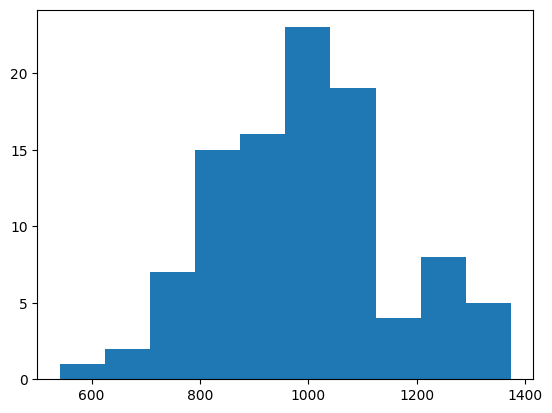

In [ ]:
plt.hist(all_end_pnl, bins=10)

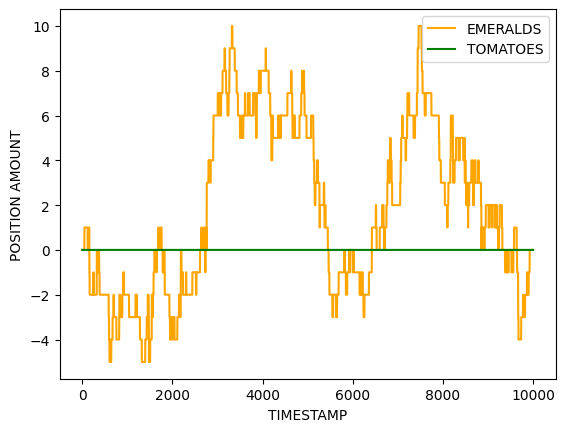

In [5]:
backtesting_result.graph_inventory()

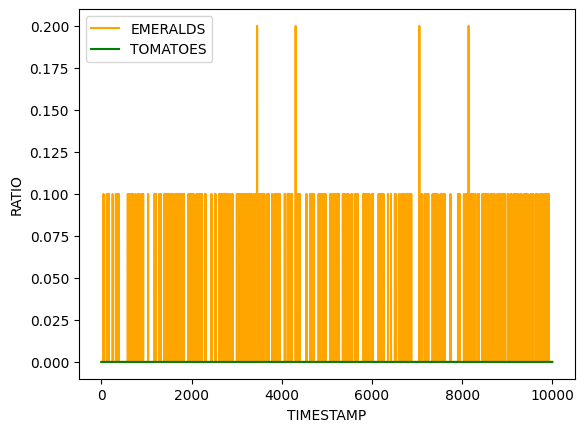

In [6]:
backtesting_result.graph_fill_ratios()

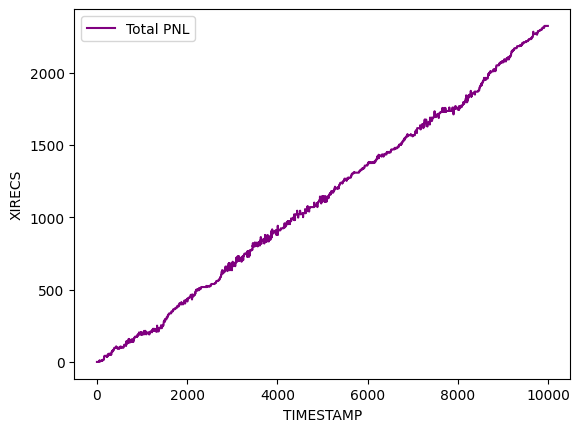

In [7]:
backtesting_result.graph_pnl()

In [10]:
backtesting_engine.get_fill_probability(1)

0.2689414213699951

(array([ 2.,  6., 19., 19., 19., 13.,  7.,  9.,  4.,  2.]),
 array([ 515.  ,  581.75,  648.5 ,  715.25,  782.  ,  848.75,  915.5 ,
         982.25, 1049.  , 1115.75, 1182.5 ]),
 <BarContainer object of 10 artists>)

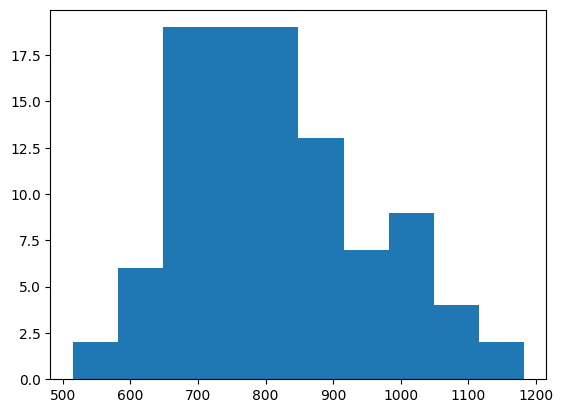

In [ ]:
plt.hist(all_end_pnl)

In [ ]:
plt.plot([i for i in range(len(total_pnl))], inventory, color="green")

NameError: name 'total_pnl' is not defined

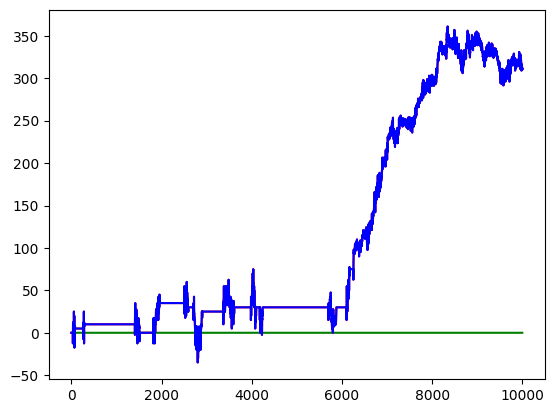

In [ ]:


plt.plot([i for i in range(len(total_pnl))], total_pnl, color="blue")